<a href="https://colab.research.google.com/github/dhans2007/DEEP_LEARNING_LAB/blob/main/EXERCISE_3_24BAD018.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
#DHANESH VC 24BAD018
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
# Use smaller dataset for faster execution
x_train = x_train[:10000]
y_train = y_train[:10000]

x_test = x_test[:2000]
y_test = y_test[:2000]

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1497s 9us/step
Training data shape: (10000, 32, 32, 3)
Testing data shape: (2000, 32, 32, 3)


In [ ]:
# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Create validation set
x_val = x_train[-2000:]
y_val = y_train[-2000:]

x_train = x_train[:-2000]
y_train = y_train[:-2000]

print("Training samples:", len(x_train))
print("Validation samples:", len(x_val))
print("Testing samples:", len(x_test))

Training samples: 8000
Validation samples: 2000
Testing samples: 2000


In [ ]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
print(class_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(
        32, (3, 3),
        activation="relu",
        input_shape=(32, 32, 3)
    ),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(
        64, (3, 3),
        activation="relu"
    ),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(
        128, (3, 3),
        activation="relu"
    ),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),

    # Dropout reduces overfitting
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=7,
    batch_size=64,
    validation_data=(x_val, y_val)
)

Epoch 1/7
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.7961 - loss: 0.5750 - val_accuracy: 0.6135 - val_loss: 1.2519
Epoch 2/7
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 88ms/step - accuracy: 0.8135 - loss: 0.5310 - val_accuracy: 0.6185 - val_loss: 1.2719
Epoch 3/7
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 98ms/step - accuracy: 0.8184 - loss: 0.5111 - val_accuracy: 0.6250 - val_loss: 1.3218
Epoch 4/7
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 93ms/step - accuracy: 0.8306 - loss: 0.4724 - val_accuracy: 0.5860 - val_loss: 1.3975
Epoch 5/7
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 94ms/step - accuracy: 0.8441 - loss: 0.4470 - val_accuracy: 0.6130 - val_loss: 1.3868
Epoch 6/7
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.8479 - loss: 0.4159 - val_accuracy: 0.6225 - val_loss: 1.3803
Epoch 7/7
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - accuracy: 0.8594 - loss: 0.3957 - val_accuracy: 0.6125 - val_loss: 1.4958


In [ ]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 1.4619871377944946
Test Accuracy: 0.6209999918937683


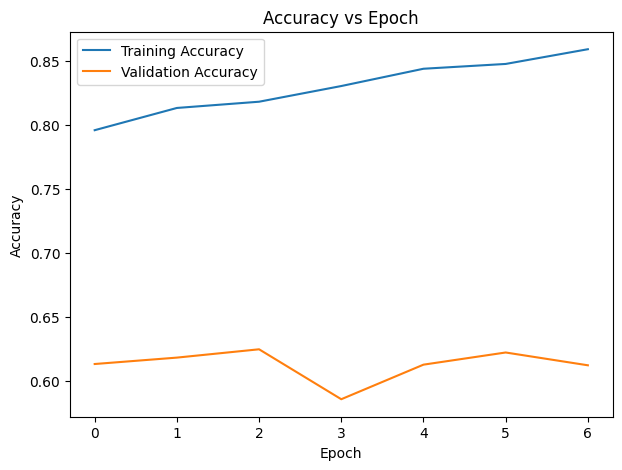

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.show()

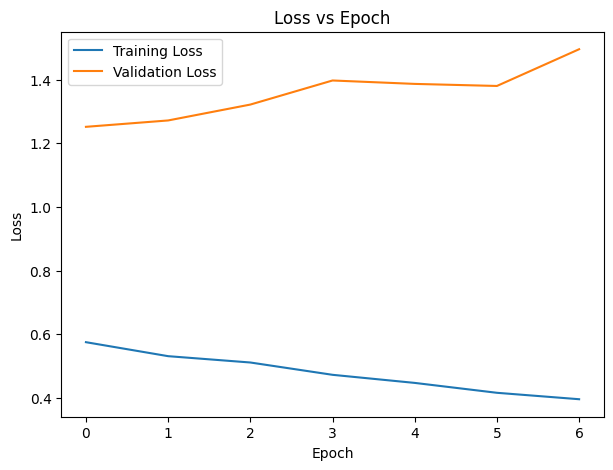

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.show()

In [ ]:
predictions = model.predict(x_test)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

print("Predictions completed.")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Predictions completed.


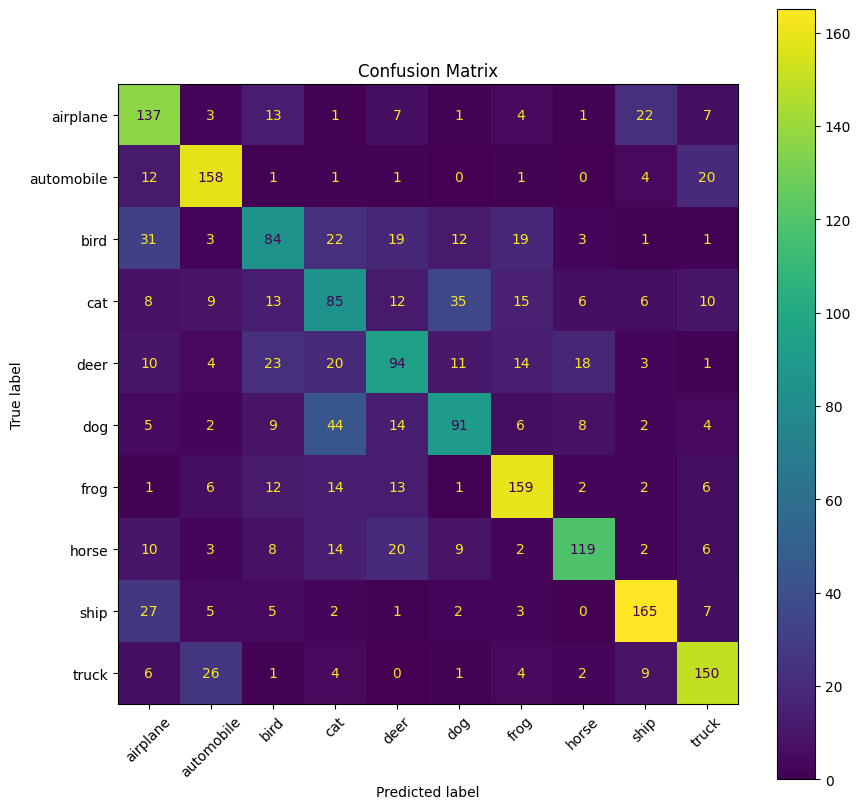

In [ ]:
cm = confusion_matrix(
    y_test.flatten(),
    predicted_classes
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10,10))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("Confusion Matrix")
plt.show()

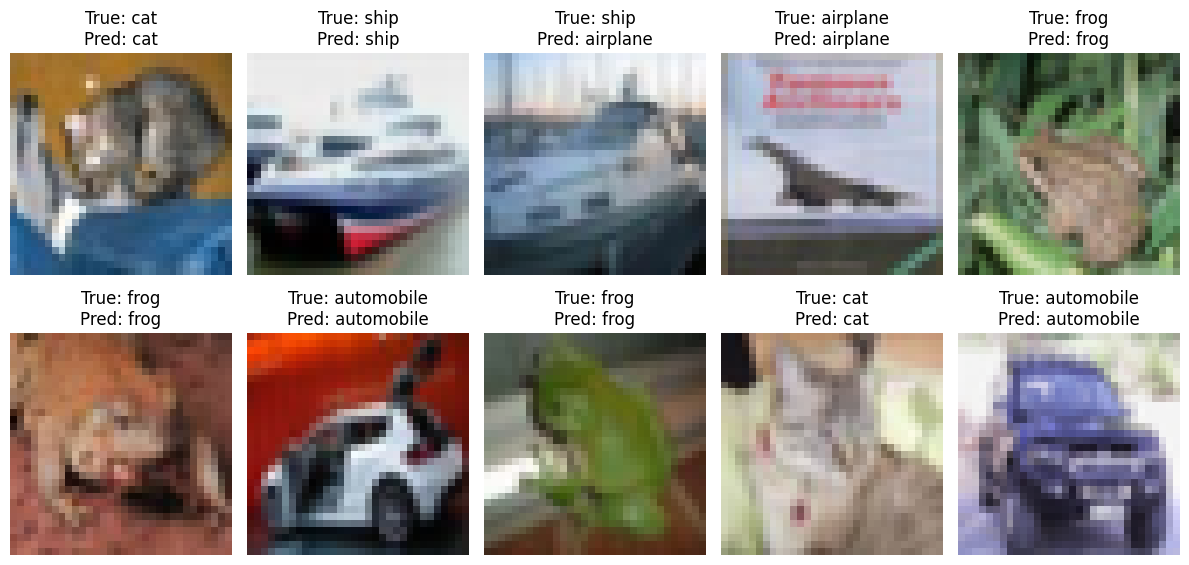

In [ ]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)

    plt.imshow(x_test[i])

    true_label = class_names[y_test[i][0]]
    predicted_label = class_names[predicted_classes[i]]

    plt.title(
        f"True: {true_label}\nPred: {predicted_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

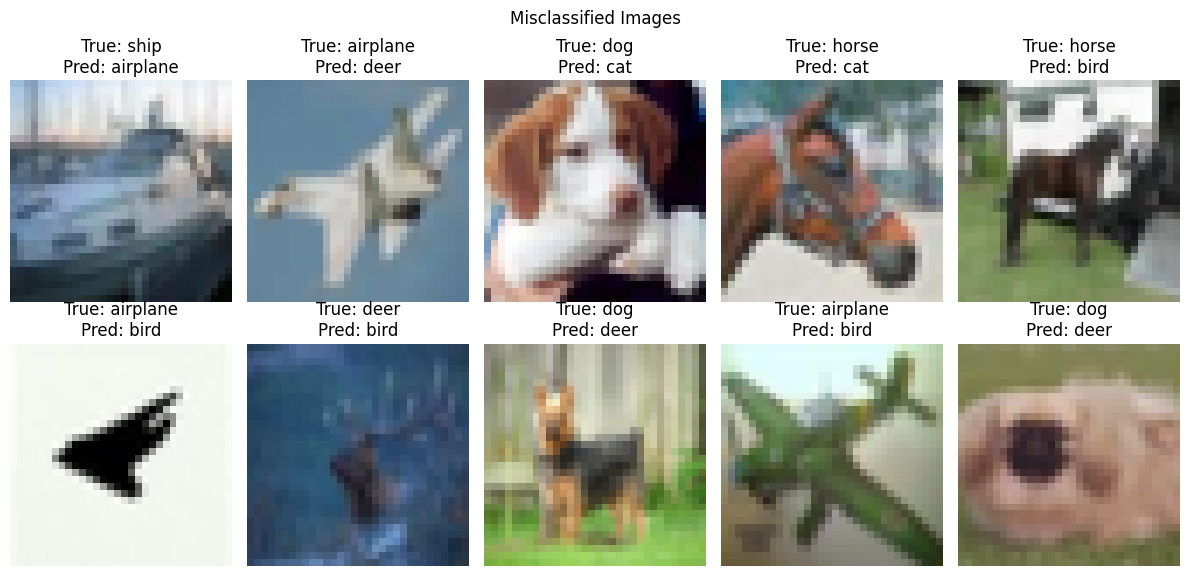

In [ ]:
misclassified = np.where(
    predicted_classes != y_test.flatten()
)[0]

plt.figure(figsize=(12,6))

for i in range(min(10, len(misclassified))):

    index = misclassified[i]

    plt.subplot(2,5,i+1)

    plt.imshow(x_test[index])

    true_label = class_names[y_test[index][0]]
    predicted_label = class_names[predicted_classes[index]]

    plt.title(
        f"True: {true_label}\nPred: {predicted_label}"
    )

    plt.axis("off")

plt.suptitle("Misclassified Images")
plt.tight_layout()
plt.show()